# MS0003: CA 2
o Submit a SINGLE Jupyter Notebook file named StudentID.ipynb, where StudentID is your matriculation number.

o Download the data file (in CSV format) posted corresponding to this Lab Quiz. You will need it for the problems.


In [1]:
# Basic Libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt # we only need pyplot
sb.set() # set the default Seaborn style for graphics
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
#linreg=LinearRegression()

# Problem 1: Classification

### a)	Print the overall statistical description of the data and plot standard statistical distributions for each variable, including for the categorical variable.                       (6)

In [2]:
data = pd.read_csv('nutrition_dataset_simp.csv', index_col=0)
data

,iron,carbohydrate,fiber,fat,water,calories,category
name,,,,,,,
Tea,0.08,0.20,0.0,0.00,99.70,1,vegetarian
Tea,0.00,1.13,0.0,0.00,98.87,0,vegetarian
Water,0.00,0.00,0.0,0.00,100.00,0,vegetarian
Water,0.15,10.95,0.4,0.20,87.40,48,vegetarian
Tea,0.07,15.72,0.0,0.00,84.20,61,vegetarian
...,...,...,...,...,...,...,...
Mushrooms,1.15,7.81,2.7,0.29,88.34,37,vegetarian
Mushrooms,0.40,4.30,0.6,0.10,92.12,22,vegetarian
Mushrooms,0.53,7.68,3.6,0.35,87.74,39,vegetarian


In [3]:
data.describe()

,iron,carbohydrate,fiber,fat,water,calories
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,2.787318,18.814687,2.618099,7.722734,59.789232,187.748698
std,7.658791,23.956734,5.929290,10.927899,27.697798,137.510870
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.410000,0.487500,0.000000,0.430000,42.165000,79.000000
50%,0.970000,6.970000,0.600000,2.910000,68.105000,155.000000
75%,2.235000,28.955000,2.600000,11.685000,80.350000,286.250000
max,123.600000,94.450000,53.200000,99.500000,100.000000,897.000000


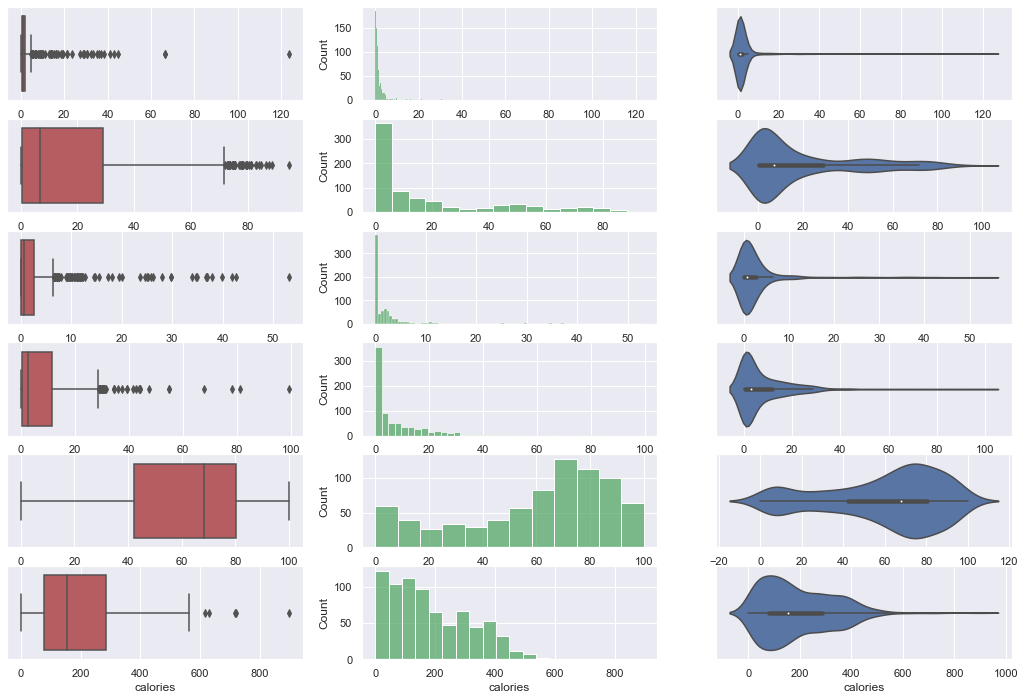

In [4]:
f, axes = plt.subplots(6, 3, figsize=(18, 12))

count = 0
for var in data:
    sb.boxplot(x = data[var], orient = "h", ax = axes[count,0],color = 'r')
    sb.histplot(data = data[var], ax = axes[count,1], color = 'g')
    sb.violinplot(x = data[var], ax = axes[count,2], color ="b")
    count += 1
    if count == 6: 
        break

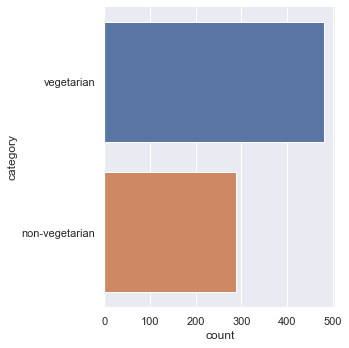

In [5]:
class_data = data['category']
sb.catplot(y = "category", data = data, kind = "count")

### b)	Calculate the ratio of “non-vegetarian/vegetarian” in category. Print this ratio. 	(3)

In [6]:
nonveg_count = data['category'].value_counts()['non-vegetarian']
veg_count = data['category'].value_counts()['vegetarian']

# Calculate the ratio and print the result
nonveg_to_veg_ratio = nonveg_count / veg_count
print("Non-Vegetarian to Vegetarian: {:.2f}".format(nonveg_to_veg_ratio))

Non-Vegetarian to Vegetarian: 0.60


### d)	Partition the dataset randomly into Train and Test datasets: 73% for Train and 27% for Test. On the Train set, fit a multi-variate 4-level Decision Tree model for the category against all six other numeric variables.  			(6)

In [7]:
Y = pd.DataFrame(data['category'])
x = pd.DataFrame(data.iloc[:,:-1])


Y_train, Y_test, x_train, x_test = train_test_split(Y, x, test_size = 0.27)

In [8]:
from sklearn.tree import DecisionTreeClassifier


# Decision Tree using Train Data
dectree = DecisionTreeClassifier(max_depth = 4)  # create the decision tree object
dectree.fit(x_train, Y_train)                    # train the decision tree model

bestmodel = dectree

### e)	Predict category using this model on both Train and Test datasets. Print the Classification Accuracy in both cases. 	(3)

In [9]:
# Predict Response corresponding to Predictors
y_train_pred = dectree.predict(x_train)
y_test_pred = dectree.predict(x_test)

# Check the Goodness of Fit (on Train Data)
print("Goodness of Fit of Model \tTrain Dataset")
print("Classification Accuracy \t:", dectree.score(x_train, Y_train))
print()

# Check the Goodness of Fit (on Test Data)
print("Goodness of Fit of Model \tTest Dataset")
print("Classification Accuracy \t:", dectree.score(x_test, Y_test))
print()

Goodness of Fit of Model 	Train Dataset
Classification Accuracy 	: 0.9053571428571429

Goodness of Fit of Model 	Test Dataset
Classification Accuracy 	: 0.875



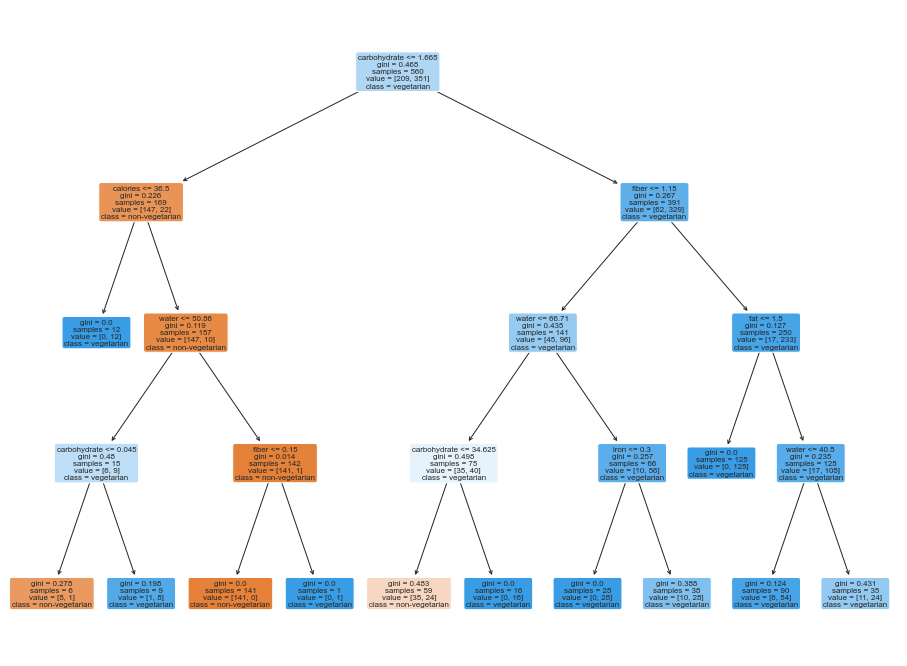

In [10]:
# Import the function plot_tree
from sklearn.tree import plot_tree

# Plot the Decision Tree model 
f, axes = plt.subplots(1, 1, figsize=(16, 12))  
plot_tree(dectree, filled=True, rounded = True, feature_names=['iron','carbohydrate','fiber','fat','water', 'calories'], 
          class_names=['non-vegetarian','vegetarian'])
plt.show()

### f)	Compute from the Confusion Matrix, the values of false positive rate (fpr) and the false negative rate (fnr) and print these values.     (3)

<AxesSubplot:>

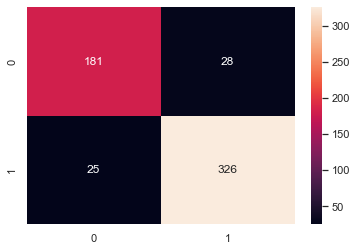

In [11]:
from sklearn.metrics import confusion_matrix
sb.heatmap(confusion_matrix(Y_train, y_train_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 12})

In [12]:
from sklearn.metrics import confusion_matrix
# Print the Accuracy Measures from the Confusion Matrix
cmTrain = confusion_matrix(Y_train, y_train_pred)
tpTrain = cmTrain[1][1] # True Positives : Y (1) predicted Y (1)
fpTrain = cmTrain[0][1] # False Positives : N (0) predicted Y (1)
tnTrain = cmTrain[0][0] # True Negatives : N (0) predicted N (0)
fnTrain = cmTrain[1][0] # False Negatives : Y (1) predicted N (0)

print("FPR Train :\t", (fpTrain/(tnTrain + fpTrain)))
print("FNR Train :\t", (fnTrain/(tpTrain + fnTrain)))

FPR Train :	 0.1339712918660287
FNR Train :	 0.07122507122507123


<AxesSubplot:>

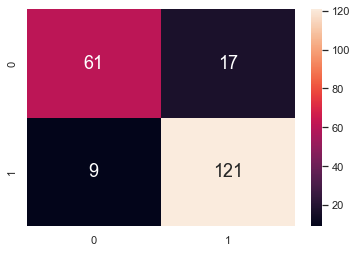

In [13]:
from sklearn.metrics import confusion_matrix
sb.heatmap(confusion_matrix(Y_test, y_test_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18})

In [14]:
from sklearn.metrics import confusion_matrix
# Print the Accuracy Measures from the Confusion Matrix
cmTrain = confusion_matrix(Y_test, y_test_pred)
tpTrain = cmTrain[1][1] # True Positives : Y (1) predicted Y (1)
fpTrain = cmTrain[0][1] # False Positives : N (0) predicted Y (1)
tnTrain = cmTrain[0][0] # True Negatives : N (0) predicted N (0)
fnTrain = cmTrain[1][0] # False Negatives : Y (1) predicted N (0)


print("FPR Train :\t", (fpTrain/(tnTrain + fpTrain)))
print("FNR Train :\t", (fnTrain/(tpTrain + fnTrain)))

FPR Train :	 0.21794871794871795
FNR Train :	 0.06923076923076923


### g) Partition the dataset again into new Train and Test datasets: 73% for Train and 27% for Test and set shuffle = False within the arguments of the train_test_split function.  On this Train set, fit a multi-variate 3-level Decision Tree model for category, plot the decision tree and comment on which model is better and why. Note: shuffle = False makes sure the split is not random.    (5)

In [15]:
Y = pd.DataFrame(data['category'])
x = pd.DataFrame(data.iloc[:,:-1])


x_train, x_test,Y_train, Y_test,new_train,new_test  = train_test_split(x,Y,data, test_size = 0.27, shuffle = False)

In [16]:
# Decision Tree using Train Data
dectree = DecisionTreeClassifier(max_depth = 3)  # create the decision tree object
dectree.fit(x_train, Y_train)                    # train the decision tree model

DecisionTreeClassifier(max_depth=3)

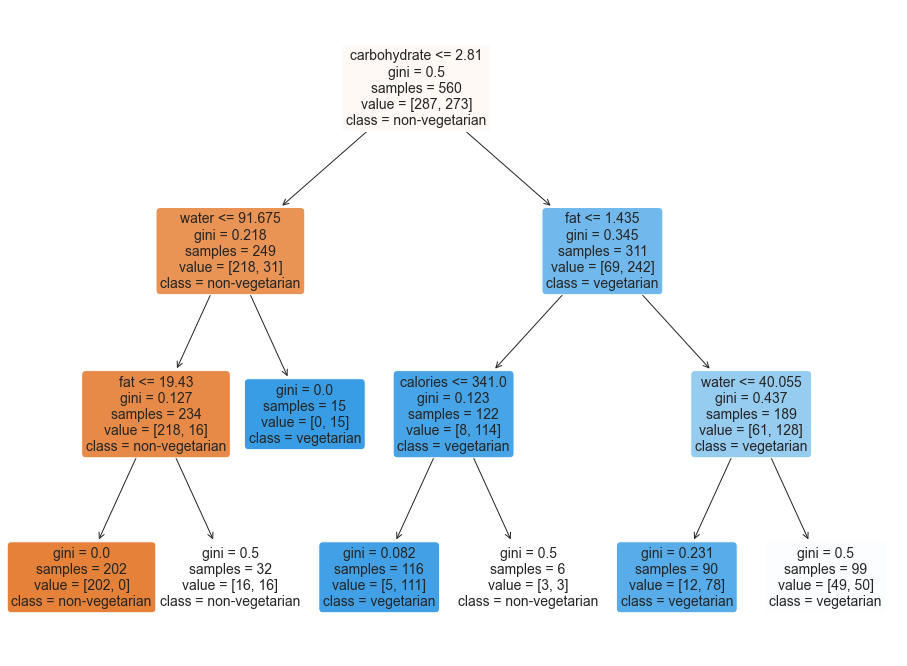

In [17]:
# Import the function plot_tree
from sklearn.tree import plot_tree

# Plot the Decision Tree model 
f, axes = plt.subplots(1, 1, figsize=(16, 12))  
plot_tree(dectree, filled=True, rounded = True, feature_names=['iron','carbohydrate','fiber','fat','water', 'calories'], 
          class_names=['non-vegetarian','vegetarian'])
plt.show()

In [18]:
# Predict Response corresponding to Predictors
y_train_pred = dectree.predict(x_train)
y_test_pred = dectree.predict(x_test)

# Check the Goodness of Fit (on Train Data)
print("Goodness of Fit of Model \tTrain Dataset")
print("Classification Accuracy \t:", dectree.score(x_train, Y_train))
print()

# Check the Goodness of Fit (on Test Data)
print("Goodness of Fit of Model \tTest Dataset")
print("Classification Accuracy \t:", dectree.score(x_test, Y_test))
print()

Goodness of Fit of Model 	Train Dataset
Classification Accuracy 	: 0.8482142857142857

Goodness of Fit of Model 	Test Dataset
Classification Accuracy 	: 0.9711538461538461



### h)	Use the decision tree from question (i) - Traverse down the tree to the bottom-right most node where the gini = 0.231. Write a block of code that extracts a new dataframe only belonging to this node with 90 samples (red box below) and give it a new variable name. Plot the countplot to show if all the variables in this node are vegetarian or non-vegetarian.   (6)

In [19]:
nodeselektor = new_train[new_train['carbohydrate']>=2.81]
nodeselektor = nodeselektor[nodeselektor['fat']>=1.435]
nodeselektor = nodeselektor[nodeselektor['water']<40.055]
nodeselektor.shape

(90, 7)

In [20]:
nodeselektor

,iron,carbohydrate,fiber,fat,water,calories,category
name,,,,,,,
Malted drink mix,0.70,71.21,0.1,9.52,2.00,428,vegetarian
Bagels,3.80,55.20,2.3,1.70,32.00,274,vegetarian
Bagels,3.98,53.00,2.3,2.10,32.70,278,vegetarian
Barley flour or meal,2.68,74.52,10.1,1.60,12.11,345,vegetarian
Barley malt flour,4.71,78.30,7.1,1.84,8.21,361,vegetarian
...,...,...,...,...,...,...,...
Paprika,123.60,63.94,37.0,7.43,7.79,276,vegetarian
Paprika,18.54,52.29,39.8,14.87,8.81,345,vegetarian
Paprika,33.53,58.35,24.6,6.41,8.84,323,vegetarian


<AxesSubplot:xlabel='category', ylabel='count'>

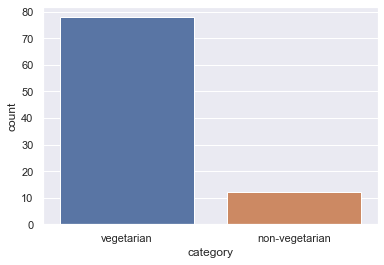

In [21]:
sb.countplot(x=nodeselektor['category'])

### i)	Create a new dataframe with the entries below. Based on your model in 1(d), predict the category for each of the combinations and use the print function to display the category prediction (Vegetarian/Non-vegetarian).  (5)

In [22]:
col1 = [3.19,66.36,0.23,2.15,0.37]
col2 = [0,44.24,5.88,47,0.74]
col3 = [0,10.5,3,2.6,0]
col4 = [8.62,22.27,0.18,20.9,0.97]
col5 = [65.09,8.06,92.3,21,79.18]
col6 = [179, 375,25,414,86]

predictors = ['iron','carbohydrate','fiber','fat','water', 'calories']
pdt = pd.DataFrame({'iron':col1,'carbohydrate':col2,'fiber':col3,'fat':col4,'water':col5, 'calories':col6})

In [23]:
classp = dectree.predict(pdt[predictors])
pdt['predicted_category'] =  classp
pdt

,iron,carbohydrate,fiber,fat,water,calories,predicted_category
0,3.19,0.00,0.0,8.62,65.09,179,non-vegetarian
1,66.36,44.24,10.5,22.27,8.06,375,vegetarian
2,0.23,5.88,3.0,0.18,92.30,25,vegetarian
3,2.15,47.00,2.6,20.90,21.00,414,vegetarian
4,0.37,0.74,0.0,0.97,79.18,86,non-vegetarian


In [24]:
print(classp)

['non-vegetarian' 'vegetarian' 'vegetarian' 'vegetarian' 'non-vegetarian']
